# Procesamiento de Audio
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

El objetivo de este Notebook es explorar técnicas básicas de procesamiento de audio utilizando varias bibliotecas de Python, se utilizan 5 de ellas para mostrar diferentes funcionalidades y capacidades en el manejo de datos de audio.

Bibliotecas utilizadas:
- Librosa
- pydub
- pyAudioAnalysis
- TorchAudio
- SoundFile

Para esto, se utilizará un archivo de audio extraído de un video de grabado en formato mp4, de una persona cantando karaoke.

Importar bibliotecas generales.

In [75]:
!pip install moviepy

In [76]:
from IPython.display import Audio, display
from moviepy.editor import VideoFileClip
import matplotlib.pyplot as plt
import numpy as np

Definir rutas de archivos.

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
DATA_PATH = '/content/drive/MyDrive/data/CDSI/T_Procesamiento_Audio'
FILE_PATH = f'{DATA_PATH}/karaoke.mp4'

In [79]:
# Cargar el video
video = VideoFileClip(FILE_PATH)

# Extraer el audio
audio = video.audio

# Guardar el audio
audio_path = f'{DATA_PATH}/karaoke_audio.wav'
audio.write_audiofile(audio_path)

MoviePy - Writing audio in /content/drive/MyDrive/data/CDSI/T_Procesamiento_Audio/karaoke_audio.wav


MoviePy - Done.


## Librosa
Lo utilizamos para ver la forma de onda, espectrograma y MFCCs del audio.

In [80]:
!pip install librosa --quiet

In [81]:
import librosa
import librosa.display

In [82]:
# Cargar el audio
audio, sr = librosa.load(audio_path, sr=None)

**Forma de la onda de audio**

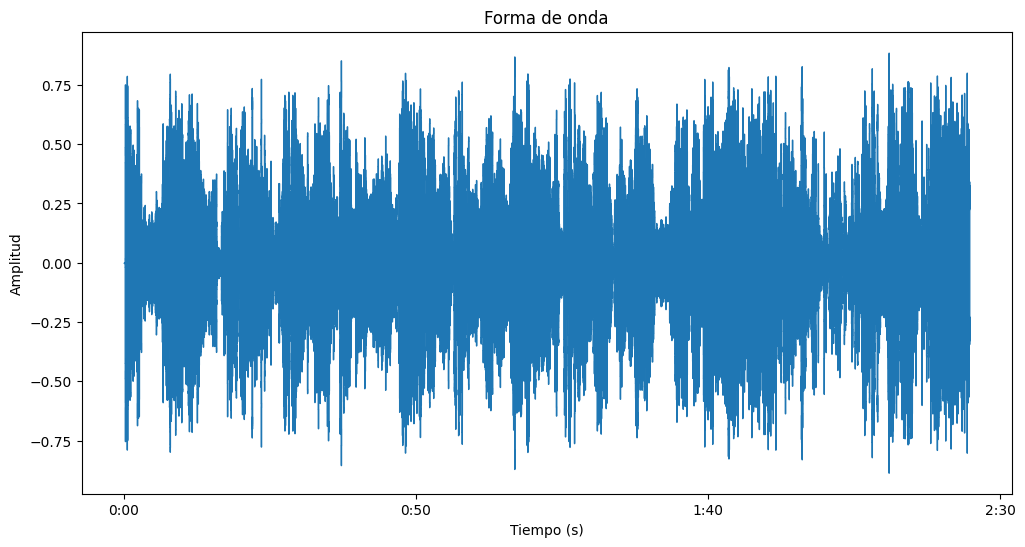

In [83]:
plt.figure(figsize=(12, 6))
librosa.display.waveshow(audio, sr=sr)
plt.title('Forma de onda')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

**Espectrograma de Mel**

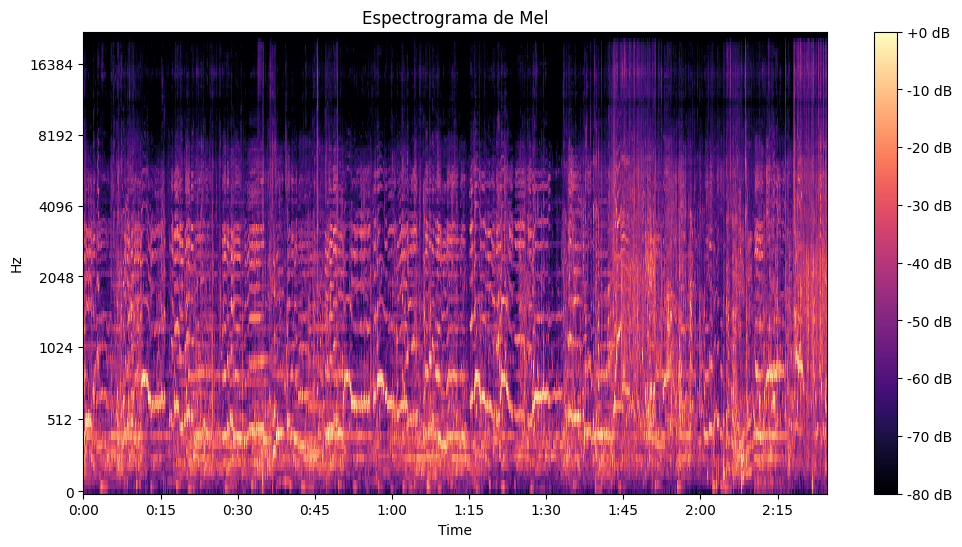

In [84]:
S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
plt.figure(figsize=(12, 6))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.show()

**Coeficientes MFCC**

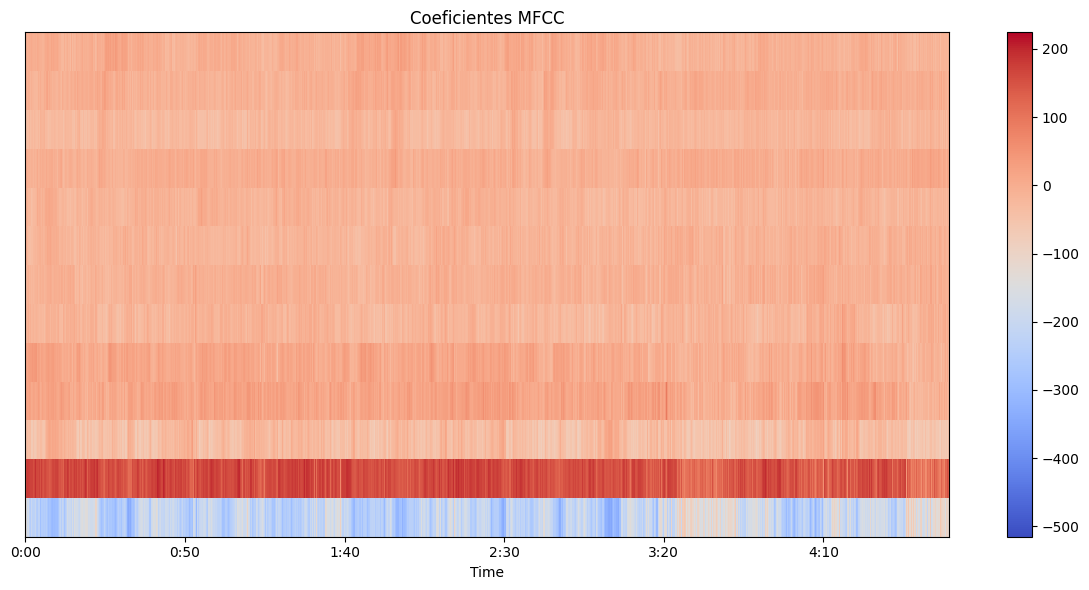

In [85]:
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
plt.figure(figsize=(12, 6))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title('Coeficientes MFCC')

plt.tight_layout()
plt.show()

**Corte de audio, mostramos ventana de 15 segundos, del segundo 30 al 45.**

In [86]:
start = 35 * sr  # 30 segundos
end = 40 * sr    # 45 segundos
audio_segment = audio[start:end]

Forma de onda, Espectrograma de Mel, y Coeficientes MFCC del segmento de audio cortado.

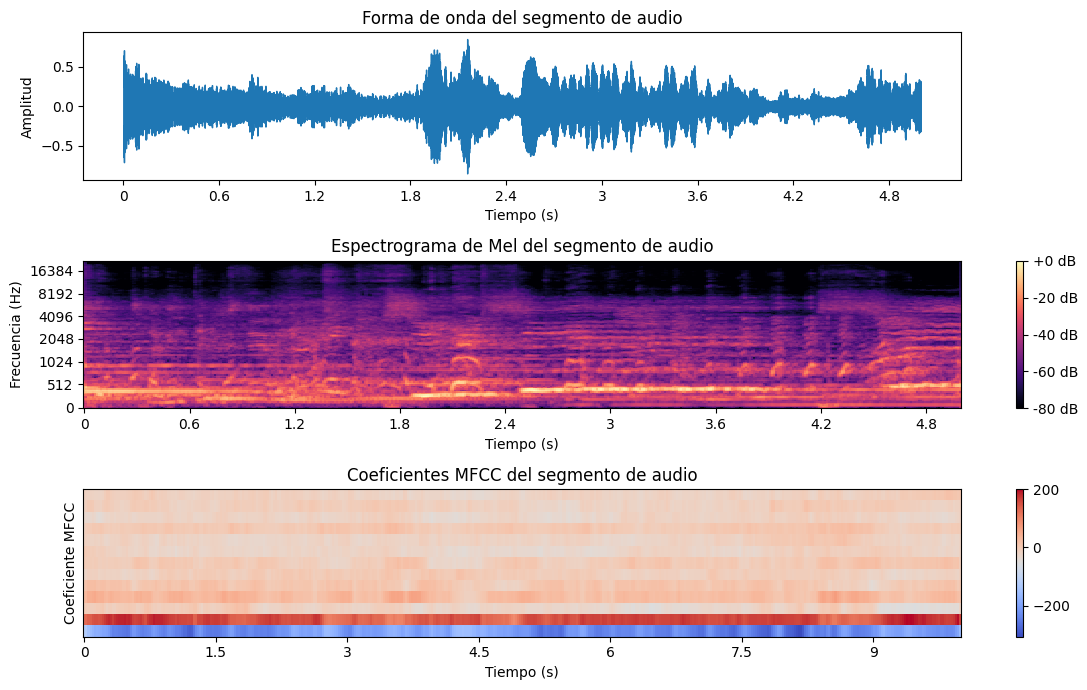

In [87]:
plt.figure(figsize=(12, 7))

# Forma de onda
ax1 = plt.subplot(3, 1, 1)
librosa.display.waveshow(audio_segment, sr=sr)
plt.title('Forma de onda del segmento de audio')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
# Añadir colorbar transparente para alinear con los otros subplots
cbar = plt.colorbar(plt.cm.ScalarMappable(), ax=ax1)
cbar.ax.set_visible(False)

# Espectrograma de Mel
ax2 = plt.subplot(3, 1, 2)
S_segment = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_mels=128)
S_dB_segment = librosa.power_to_db(S_segment, ref=np.max)
librosa.display.specshow(S_dB_segment, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel del segmento de audio')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')

# Coeficientes MFCC
ax3 = plt.subplot(3, 1, 3)
mfccs_segment = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=13)
librosa.display.specshow(mfccs_segment, x_axis='time')
plt.colorbar()
plt.title('Coeficientes MFCC del segmento de audio')
plt.xlabel('Tiempo (s)')
plt.ylabel('Coeficiente MFCC')

plt.tight_layout()
plt.show()

## pydub
Lo utilizamos para manipulación básica de audio, como normalización, compresión, pasar filtro pasa altas.

In [88]:
from pydub import AudioSegment
from pydub.effects import normalize, compress_dynamic_range

In [89]:
# Cargar el archivo de audio WAV
audio = AudioSegment.from_wav(audio_path)

En el audio, durante los primeros 20 segundos (aproximadamente) de la grabación hay varias personas hablando. Usando pydub, se puede cortar esa parte del audio y quedarse solo con la parte donde la persona está cantando.

In [90]:
singing_part = audio[20000:]

Se aplica una **normalización y compresión al segmento de audio** de la parte cantada para mejorar la calidad del sonido.
Posteriormente se **aplica un filtro pasa-altas** para eliminar ruidos de baja frecuencia.

In [91]:
# Normalizar
normalized_audio = normalize(singing_part)

# Comprimir rango dinámico
compressed_audio = compress_dynamic_range(normalized_audio)

# Aplicar filtro pasa-altas
filtered_audio = compressed_audio.high_pass_filter(100)

In [92]:
# Guardar el audio procesado
processed_audio_path = f'{DATA_PATH}/karaoke_audio_processed.wav'
filtered_audio.export(processed_audio_path, format='wav')

# Guardar audio no procesado con 20 segundos de recorte
cut_audio_path = f'{DATA_PATH}/karaoke_audio_cut.wav'
singing_part.export(cut_audio_path, format='wav')

<_io.BufferedRandom name='/content/drive/MyDrive/data/CDSI/T_Procesamiento_Audio/karaoke_audio_cut.wav'>

Ahora se **comparan las formas de onda antes y después del procesamiento** con pydub.

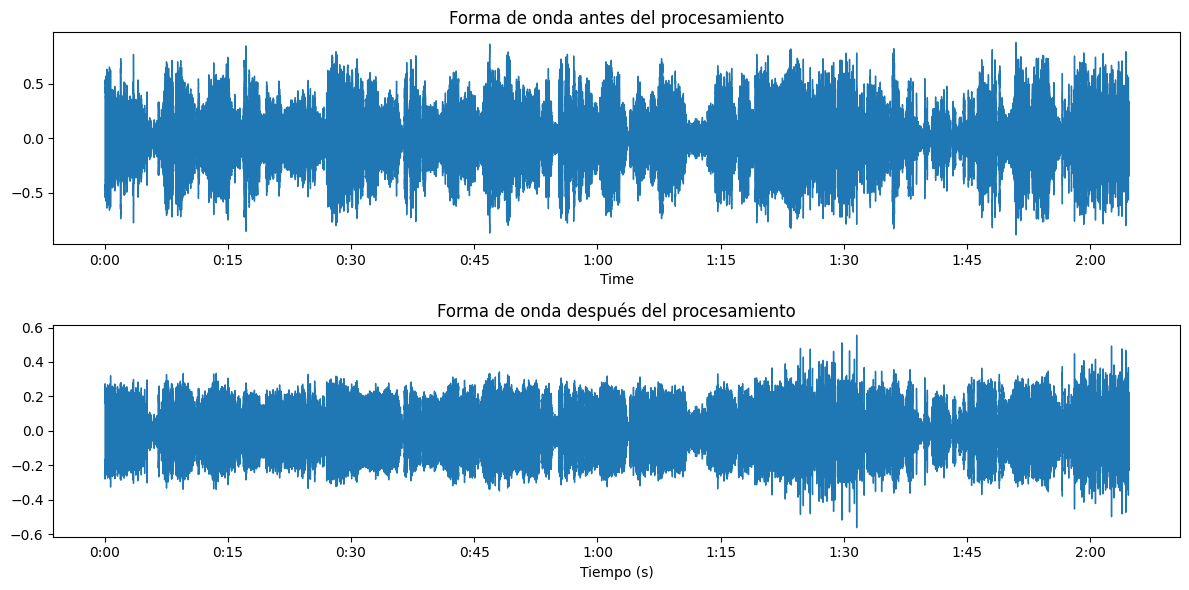

In [93]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
singing_samples = np.array(singing_part.get_array_of_samples()).astype(np.float32) / (2**15)

if singing_part.channels == 2:
    singing_samples = singing_samples.reshape((-1, 2)).mean(axis=1)

librosa.display.waveshow(singing_samples, sr=singing_part.frame_rate)
plt.title('Forma de onda antes del procesamiento')

plt.subplot(2, 1, 2)
filtered_samples = np.array(filtered_audio.get_array_of_samples()).astype(np.float32) / (2**15)

if filtered_audio.channels == 2:
    filtered_samples = filtered_samples.reshape((-1, 2)).mean(axis=1)

librosa.display.waveshow(filtered_samples, sr=filtered_audio.frame_rate)
plt.title('Forma de onda después del procesamiento')
plt.xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

Se facilitan ambos audios para su reproducción.

Audio original:

In [94]:
display(audio.from_file(cut_audio_path, rate=sr))

Audio procesado:

In [95]:
display(audio.from_file(processed_audio_path))

## pyAudioAnalysis
Lo utilizamos para análisis de características de corto plazo y segmentación de audio.

In [96]:
!pip install pyAudioAnalysis eyed3 hmmlearn imblearn plotly --quiet

In [97]:
from pyAudioAnalysis import audioBasicIO
from pyAudioAnalysis import ShortTermFeatures
from pyAudioAnalysis import audioSegmentation as aS

In [98]:
# Leer el archivo de audio
[sampling_rate, signal] = audioBasicIO.read_audio_file(processed_audio_path)

# Convertir a mono
if signal.ndim > 1:
    signal = signal.mean(axis=1)

Se extraen segmentos de 50 ms con un overlap de 25 ms para analizar características de corto plazo del audio.

In [99]:
f, f_names = ShortTermFeatures.feature_extraction(signal, sampling_rate, 0.050*sampling_rate, 0.025*sampling_rate)

**Se muestran Zero Crossing Rate y Energía del audio procesado.**

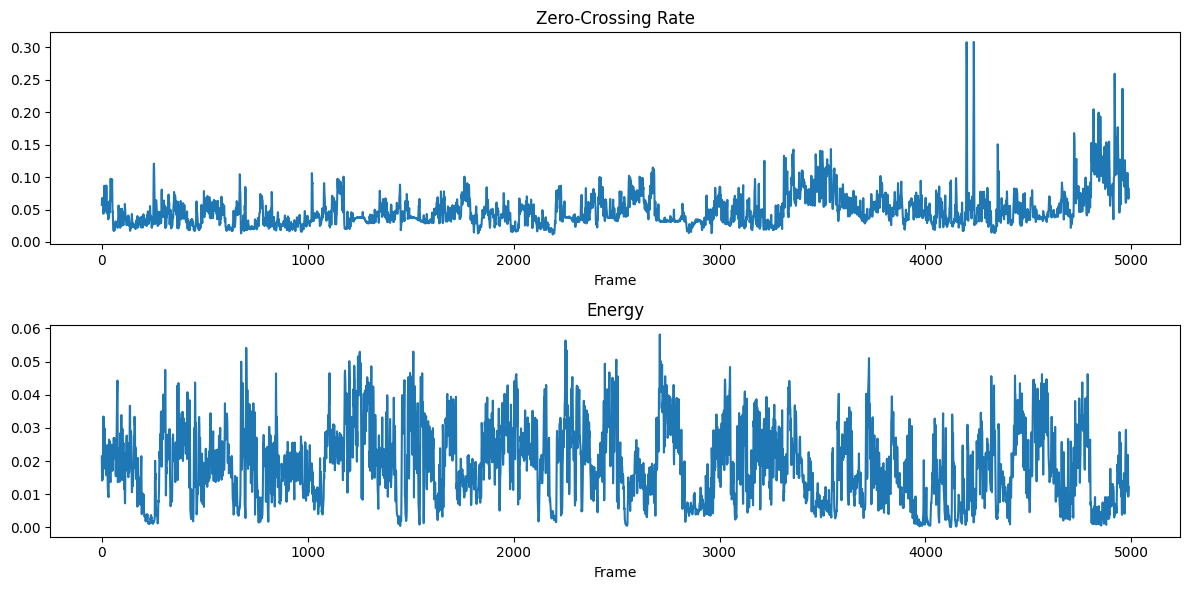

In [100]:
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(f[0,:])
plt.title('Zero-Crossing Rate')
plt.xlabel('Frame')

plt.subplot(2,1,2)
plt.plot(f[1,:])
plt.title('Energy')
plt.xlabel('Frame')

plt.tight_layout()
plt.show()

**Detección de segmentos de silencio en el audio.**

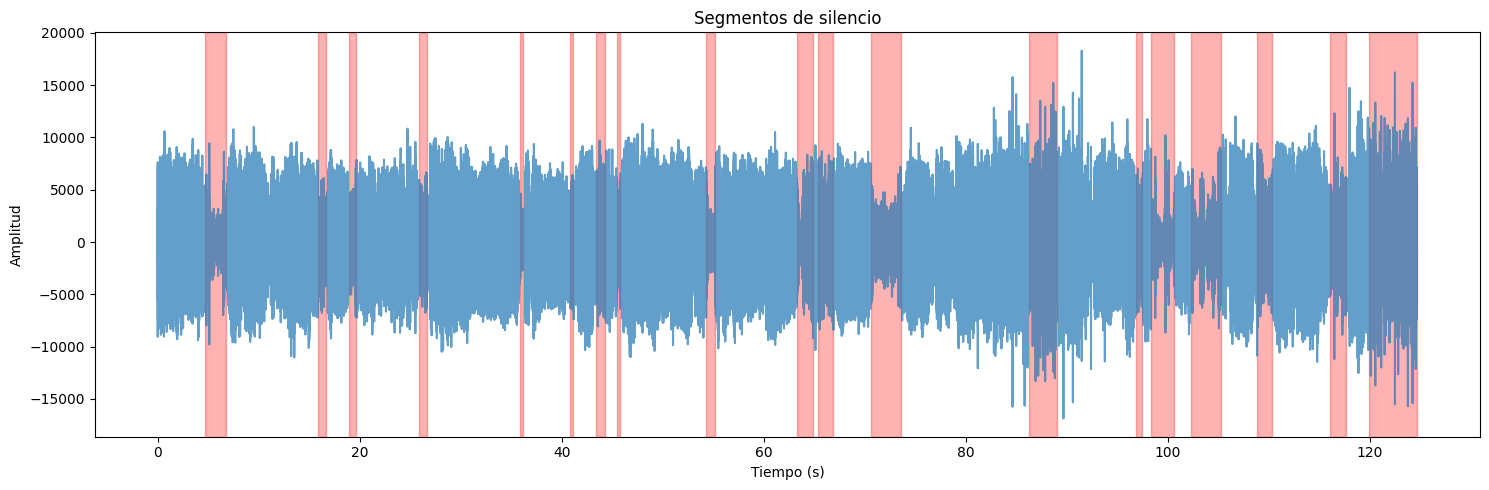

In [101]:
segments = aS.silence_removal(signal, sampling_rate, 0.050, 0.050, smooth_window=1.0, weight=0.3, plot=False)

# Graficar la señal
plt.figure(figsize=(15, 5))
time = np.arange(len(signal)) / sampling_rate
plt.plot(time, signal, alpha=0.7)

# Destacar los segmentos con silencio
for i, seg in enumerate(segments):
    if i < len(segments) - 1:
        plt.axvspan(seg[1], segments[i+1][0], alpha=0.3, color='red')

# Segmentos del inicio y final
if segments[0][0] > 0:
    plt.axvspan(0, segments[0][0], alpha=0.3, color='red')
total_duration = len(signal) / sampling_rate
if segments[-1][1] < total_duration:
    plt.axvspan(segments[-1][1], total_duration, alpha=0.3, color='red')

plt.title('Segmentos de silencio')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

## TorchAudio
Lo utilizamos para remuestrar nuestro archivo de audio. Trabaja con tensores de PyTorch.

In [102]:
# Instalar codecs de audio
!apt-get update && apt-get install -y ffmpeg

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed

In [103]:
# Instalar torchcodec compatible con versión de torch instalada en colab (2.9.0+cpu)
!pip install torchcodec==0.9.0

In [104]:
import torch
import torchcodec
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt

In [105]:
# Cargar el audio
waveform, sample_rate = torchaudio.load(processed_audio_path)

**Remuestreo**

In [106]:
# Se hace el remuestreo a 8000Hz
new_sample_rate = 8000
resampler = T.Resample(sample_rate, new_sample_rate)
waveform_resampled = resampler(waveform)

In [107]:
print(f"Muestreo original: {sample_rate} Hz -> Remuestreo: {new_sample_rate} Hz")

Muestreo original: 44100 Hz -> Remuestreo: 8000 Hz


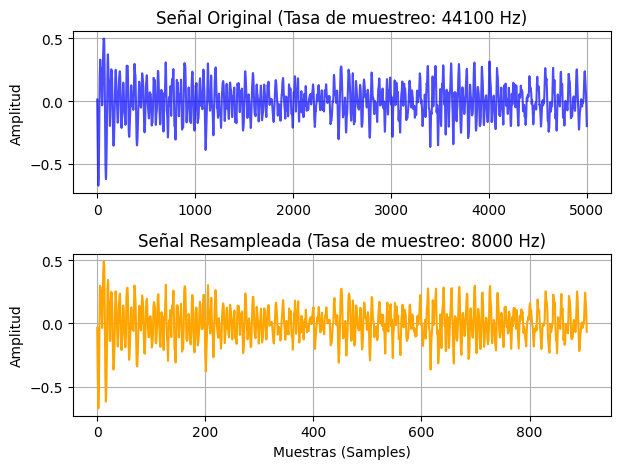

In [108]:
plt.subplot(2, 1, 1)
plt.plot(waveform[0][:5000].numpy(), color='blue', alpha=0.7)
plt.title(f"Señal Original (Tasa de muestreo: {sample_rate} Hz)")
plt.ylabel("Amplitud")
plt.grid(True)


plt.subplot(2, 1, 2)
num_samples_fragment = int(5000 * new_sample_rate / sample_rate)
plt.plot(waveform_resampled[0][:num_samples_fragment].numpy(), color='orange')
plt.title(f"Señal Resampleada (Tasa de muestreo: {new_sample_rate} Hz)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras (Samples)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Soundfile

Soundfile trabaja con los archivos como si fueran vectores de Numpy. Lo podemos utilizar para mostrar los metadatos y separar el audio en segmentos y obtener el RMS (Root Mean Square).

In [109]:
import soundfile as sf

**Obtener metadatos**

In [110]:
with sf.SoundFile(audio_path) as f:
    print(f"> Tasa de muestreo: {f.samplerate} Hz")
    print(f"> # Canales: {f.channels}")
    print(f"> Formato: {f.format_info} ({f.format})")
    print(f"> Duración: {len(f) / f.samplerate:.2f} segundos")

> Tasa de muestreo: 44100 Hz
> # Canales: 2
> Formato: WAV (Microsoft) (WAV)
> Duración: 144.69 segundos


**Separar en dos partes y obtener el RMS de cada uno**

In [111]:
data, samplerate = sf.read(audio_path)

# Separar el audio en dos partes
first_segment = data[int(100 * samplerate):]
second_segment = data[:int(100 * samplerate)]

In [112]:
def calculate_rms(signal):
    return np.sqrt(np.mean(signal**2))

In [113]:
# RMS
rms_1st = calculate_rms(first_segment)
rms_2nd = calculate_rms(second_segment)

print(f"RMS:")
print(f"> RMS primer segmento: {rms_1st:.4f}")
print(f"> RMS segundo segmento: {rms_2nd:.4f}")

RMS:
> RMS primer segmento: 0.1632
> RMS segundo segmento: 0.1820
